In [1]:
#####################################################################
# Main file to calibrate the Maréchal approximation for the LGS mode
# 
# The reference file is ./config/GPAO_LGS_VIS.ini
#
# The script loops the TIPTOP function 'overallSimulation' on the
# physical different parameters to find the coefficient of their
# dependency
# 
# Created: 09/19/2023 (mm/dd/yyyy)
# Author: Anthony Berdeu (LESIA - Observatoire de Paris)
# Modified: 06/02/2025 (mm/dd/yyyy)
#   - Adapting to LGS mode
# Author: Anthony Berdeu (LIRA - Observatoire de Paris)
#####################################################################

In [2]:
# IMPORTING LIBRARIES #
#######################

# Python
import os
import numpy as np
import configparser

# ASPRO and tiptop
import aspro as aspro
import fit_tiptop as fit_tiptop

Cupy import failed. P3 will fall back to CPU use.
Cupy import failed. MASTSEL will fall back to CPU use.
Cupy import failed. SEEING will fall back to CPU use.


In [4]:
# PARAMETERS #
##############

# Mode to calibrate
flag_mode = 'LGS_VIS' # LGS_VIS/LGS_IR
name_config = 'GPAO_' + flag_mode

# Global paths
path = os.getcwd() + '/'
path_config_0 = path + 'config_0/'
path_results = path + 'results/Maréchal_calibration/' + flag_mode + '/'


# Default parameters
lambda_sci = 2.2e-06 # Wavelength of the science channel (m)

# # Wavelength of the HO NGS channel (m)
# Convertion magnitude to flux / Magnitude 0-point (ph/s/m2 for mag=0)
# Number of corrected modes corrected models (to compute the equivalent DM number of actuators)
# Loop frequency
if flag_mode[4:7] == 'VIS':
    lambda_ngs = 750e-9
    mag2flux = 2.63e10
    n_mode_AO_LO = 4
    mag_ngs_LO = 14 # Magnitude of the NGS for the LO
elif flag_mode[4:7] == 'IR':
    lambda_ngs = 2.2e-6
    mag2flux = 1.66e9
    n_mode_AO_LO = 44
    mag_ngs_LO = 10 # Magnitude of the NGS for the LO
else:
    raise ValueError(flag_mode + \
        ' -> Unknown mode (*_VIS / *_IR)')   

r_0 = 0.100 # Fried's parameter @500 nm (m?)
v_0 = 15.0 # Wind speed of the turbulence layer (m.s-1)
h_0 = 1000.0 # Altitude of the turbulent layer (m)


n_mode_AO_LGS = 500 # Number of corrected modes
f_loop_LGS = 1000.0 # Loop frequency
f_loop_LO = 500.0 # Loop frequency
g_loop_LGS = 0.5 # Loop gain
g_loop_LO = 0.3 # Loop gain
sigRON = 0.2 # Readout noise of the camera

zenith_angle = 0
theta_LGS = 0 # Added to the zenith_angle
theta_LO = 0 # Added to the zenith_angle

WFS_transmission = 0.3 # Global transmission of the WFS channel



In [ ]:
# PREPARING DEFAULT CONFIGURATION #
###################################

##### Miscellaneous #####
# Secant of the zenith angle
airmass = 1/np.cos(np.radians(zenith_angle))
##### Miscellaneous #####

##### Creating folders #####
if not os.path.exists(path_results):
    os.makedirs(path_results)
##### Creating folders #####

###### Opening default configuration ######
config_0 = configparser.ConfigParser()
config_0.optionxform = str # Needed to be case sensitive
config_0.read(path_config_0 + name_config + '.ini')
###### Opening default configuration ######

###### Updating config ######
# Atmosphere
config_0['atmosphere']['Seeing'] = '%f'%(aspro.r02seeing(r_0))
config_0['atmosphere']['Cn2Heights'] = '[%f]'%(h_0)
config_0['atmosphere']['WindSpeed'] = '[%f]'%(v_0)

# Wavelength
config_0['sources_LO']['Wavelength'] = '[%e]'%(lambda_ngs)
config_0['sources_science']['Wavelength'] = '[%e]'%(lambda_sci)

# Angle
config_0['telescope']['ZenithAngle'] = '%f'%(zenith_angle)
config_0['sources_HO']['Zenith'] = '[%f]'%(theta_LGS)
config_0['sources_LO']['Zenith'] = '[%f]'%(theta_LO)
config_0['sources_science']['Zenith'] = '[%f]'%(0)

# Loop configuration
config_0['sensor_HO']['SigmaRON'] = '%f'%(sigRON)
config_0['RTC']['LoopGain_HO'] = '%f'%(g_loop_LGS)
config_0['RTC']['SensorFrameRate_HO'] = '%f'%(f_loop_LGS)
config_0['sensor_LO']['SigmaRON'] = '%f'%(sigRON)
config_0['RTC']['LoopGain_LO'] = '%f'%(g_loop_LO)
config_0['RTC']['SensorFrameRate_LO'] = '%f'%(f_loop_LO)

# Number of DM / AO cutoff frequency
[eqDM_pitch, eqDMn_act] = aspro.modes2eqDM(n_mode_AO_LGS, eval(config_0['telescope']['TelescopeDiameter']))
config_0['DM']['NumberActuators'] = '[%i]'%(eqDMn_act)
config_0['DM']['DmPitchs'] = '[%f]'%(eqDM_pitch)

# Lenslet diameter
D_WFS_LO = \
    eval(config_0['telescope']['TelescopeDiameter']) / \
    eval(config_0['sensor_LO']['NumberLenslets'])[0]
D_WFS_LGS = \
    eval(config_0['telescope']['TelescopeDiameter']) / \
    eval(config_0['sensor_HO']['NumberLenslets'])[0]
    
# Lenslet number of photons
# flux = mag2flux*10^(-mag/2.5)
# nph = transmission * flux * D_WFS_LO^2 / framerate
nph_sub = WFS_transmission * D_WFS_LO**2 * \
    mag2flux*10**(-mag_ngs_LO/2.5) / \
    eval(config_0['RTC']['SensorFrameRate_LO'])
config_0['sensor_LO']['NumberPhotons'] = '[%s]'%(nph_sub)

# Adding section for the Strehl coefficients
config_0.add_section('Strehl')
###### Updating config ######

###### Saving default config ######
with open(path_results + 'config_0.ini', 'w') \
    as configfile: config_0.write(configfile)
###### Saving default config ######

LO part is present
******** HO PSD science and NGSs directions
SLAO case adding cone effect
extra error in nm RMS:  0
extra error spatial frequency exponent:  -2
extra error in nm RMS (LO):  0
extra error spatial frequency exponent (LO):  -2
Required time for total calculation (ms)	 : 346.695423
Required time for AO system model init (ms)	 : 3.358603
Required time for frequency domain init (ms)	 : 85.371971
Required time for final PSD calculation (ms)	 : 244.954348
Required time for WFS reconstructors init (ms)	 : 3.119707
Required time for controller instantiation (ms)	 : 4.283905
Required time for fitting PSD calculation (ms)	 : 1.719713
Required time for aliasing PSD calculation (ms)	 : 159.811020
Required time for ST PSD calculation (ms)	 : 2.137184
Required time for focal Aniso PSD calc. (ms)	 : 44.069529
Required time for extra PSD (LO) calc. (ms)	 : 8.798122
Required time for tilt filter calculation (ms)	 : 20.989895
PSD step: 0.030851779706970468
PSD freq range: 7.8980556049844

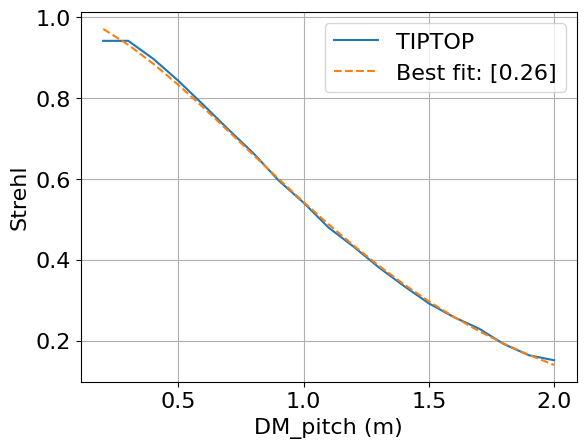

In [5]:
# CALIBRATION OF THE GEOMETRIC ERROR #
######################################

##### Parameters #####
# File parameter
name_error = 'geom'
coeff_0 = [0.5]

# Loop on the actuator pitch accross the pupil
if flag_mode[4:7] == 'VIS':
    var_min = 0.2
    var_max = 2.0
    var_delta = 0.1
elif flag_mode[4:7] == 'IR':
    var_min = 0.9
    var_max = 2.0
    var_delta = 0.1
else:
    raise ValueError(flag_mode + \
        ' -> Unknown mode (*_VIS / *_IR)') 

var_nb = round((var_max-var_min)/var_delta+1)
list_val = np.zeros([var_nb, 1])
list_val[:,0] = np.linspace(var_min, var_max, var_nb)

def update_config(config, var):
    config['DM']['NumberActuators'] = '[%i]'\
        %(np.floor(eval(config['telescope']['TelescopeDiameter'])/var[0])+1)
    config['DM']['DmPitchs'] = '[%f]'%(var[0])

    # Removing photon noise
    config['sensor_HO']['NumberPhotons'] = '[%s]'%(10000)
    config['sensor_LO']['NumberPhotons'] = '[%s]'%(10000)

    # Removing readout noise
    config['sensor_HO']['SigmaRON'] = '%f'%(0.0)
    config['sensor_LO']['SigmaRON'] = '%f'%(0.0)

    # Removing cone effect
    config['atmosphere']['Cn2Heights'] = '[%f]'%(0.0)
    
    # Removing servo-lag
    config['atmosphere']['WindDirection'] = '[%f]'%(0.0)
    config['atmosphere']['WindSpeed'] = '[0.01]'
    return config

x_label = ['DM_pitch (m)']
##### Parameters #####


##### Simulation and fitting #####
[SR, coeff, SR_0] = fit_tiptop.calib_error( \
    path_results, name_error, list_val, \
    lambda config, var:update_config(config, var), \
    lambda coeff, list_val:aspro.Strehl_geom(coeff, airmass, list_val, r_0, lambda_sci), \
    coeff_0, x_label)
print('SR_0: %f'%(SR_0))
##### Simulation and fitting #####

##### Storing and saving ######
config_0['Strehl']['geom'] = np.array2string(np.append(coeff,SR_0), separator=', ')
with open(path_results + 'config_0.ini', 'w') \
    as configfile: config_0.write(configfile)
##### Storing and saving ######

LO part is present
******** HO PSD science and NGSs directions
SLAO case adding cone effect
extra error in nm RMS:  0
extra error spatial frequency exponent:  -2
extra error in nm RMS (LO):  0
extra error spatial frequency exponent (LO):  -2
Required time for total calculation (ms)	 : 252.221823
Required time for AO system model init (ms)	 : 4.491568
Required time for frequency domain init (ms)	 : 91.316700
Required time for final PSD calculation (ms)	 : 148.353338
Required time for WFS reconstructors init (ms)	 : 1.061916
Required time for controller instantiation (ms)	 : 1.995564
Required time for fitting PSD calculation (ms)	 : 1.027346
Required time for aliasing PSD calculation (ms)	 : 61.882496
Required time for focal Aniso PSD calc. (ms)	 : 47.842979
Required time for extra PSD (LO) calc. (ms)	 : 9.988308
Required time for tilt filter calculation (ms)	 : 21.538734
PSD step: 0.030851779706970468
PSD freq range: 7.89805560498444
PSD shape: (2, 256, 256)
oversampling: 1
sensor_scien

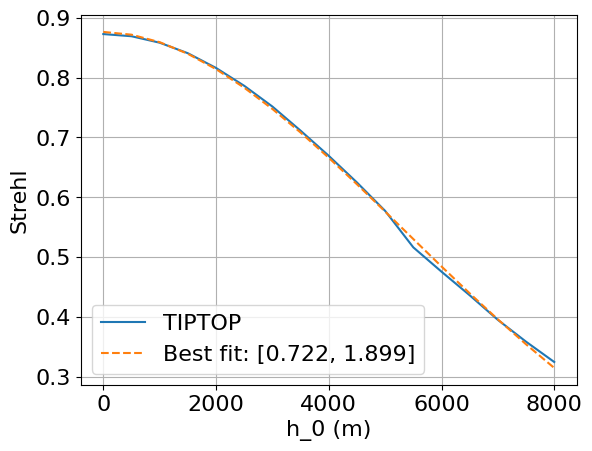

In [6]:
# CALIBRATION OF THE CONE EFFECT #
##################################

##### Parameters #####
# File parameter
name_error = 'cone'
coeff_0 = [0.5, 2]

# Loop on the actuator pitch accross the pupil
var_min = 0.0
var_max = 8000.0
var_delta = 500.0
var_nb = round((var_max-var_min)/var_delta+1)
list_val = np.zeros([var_nb, 1])
list_val[:,0] = np.linspace(var_min, var_max, var_nb)


def update_config(config, var):
    config['atmosphere']['Cn2Heights'] = '[%f]'%(var[0])
    return config

x_label = ['h_0 (m)']
##### Parameters #####


##### Simulation and fitting #####
h_lgs = eval(config_0['sources_HO']['Height'])
D_tel = eval(config_0['telescope']['TelescopeDiameter'])
[SR, coeff, SR_0] = fit_tiptop.calib_error( \
    path_results, name_error, list_val, \
    lambda config, var:update_config(config, var), \
    lambda coeff, list_val:aspro.Strehl_cone(coeff, airmass, list_val, h_lgs, D_tel, r_0, lambda_sci), \
    coeff_0, x_label)
print('SR_0: %f'%(SR_0))
##### Simulation and fitting #####

##### Storing and saving ######
config_0['Strehl']['cone'] = np.array2string(coeff, separator=', ')
with open(path_results + 'config_0.ini', 'w') \
    as configfile: config_0.write(configfile)
##### Storing and saving ######

LO part is present
******** HO PSD science and NGSs directions
SLAO case adding cone effect
extra error in nm RMS:  0
extra error spatial frequency exponent:  -2
extra error in nm RMS (LO):  0
extra error spatial frequency exponent (LO):  -2
Required time for total calculation (ms)	 : 226.014853
Required time for AO system model init (ms)	 : 1.919746
Required time for frequency domain init (ms)	 : 79.399109
Required time for final PSD calculation (ms)	 : 144.330978
Required time for aliasing PSD calculation (ms)	 : 62.780380
Required time for focal Aniso PSD calc. (ms)	 : 33.938646
Required time for extra PSD (LO) calc. (ms)	 : 14.214277
Required time for tilt filter calculation (ms)	 : 16.979218
PSD step: 0.030851779706970468
PSD freq range: 7.89805560498444
PSD shape: (2, 256, 256)
oversampling: 1
sensor_science.PixelScale: 14
******** LO PART
******** LO PSF - NGS directions (1 sub-aperture)
SR(@ 750 nm)        : 0.44212
FWHM(@ 750 nm) [mas]: 68.651
EE                   : 0.48030
ma

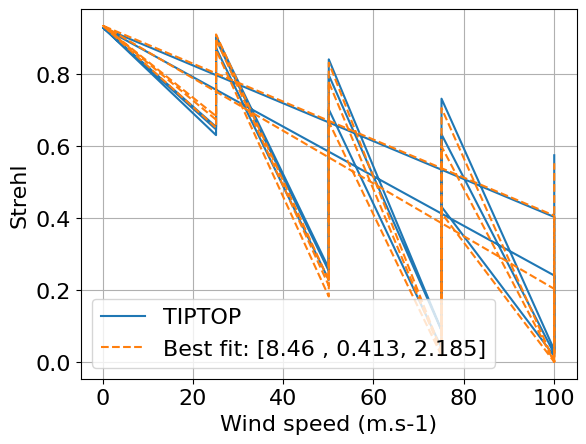

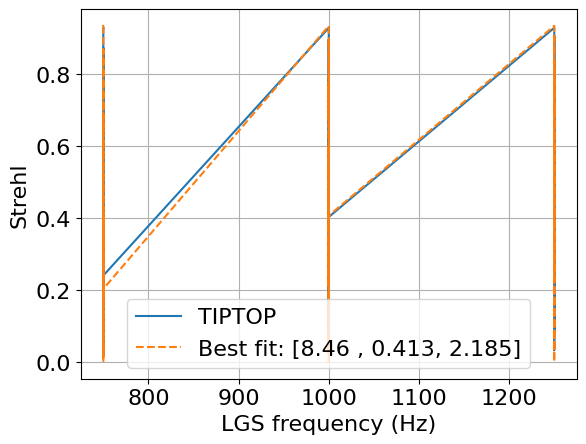

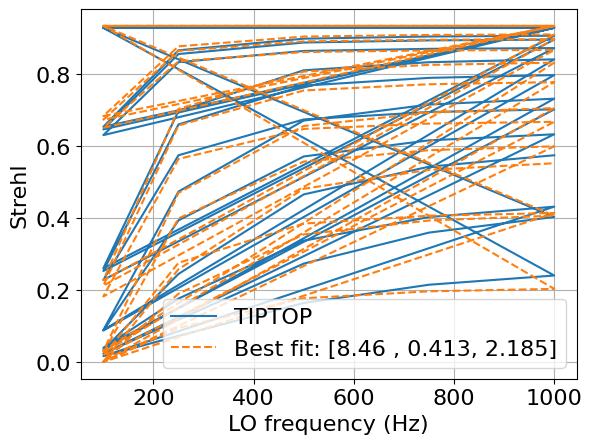

In [7]:
# CALIBRATION OF THE LAG ERROR #
################################

##### Parameters #####
# File parameter
name_error = 'lag'
coeff_0 = [3.0, 0.3, 5/3]

# Building test grid
n_v = 5
list_v = np.linspace(0.1, 100.1, n_v)
list_f_LGS = np.array([750, 1000, 1250])
list_f_LO = np.array([100, 250, 500, 750, 1000])
n_f_LO = list_f_LO.shape[0]
n_f_LGS = list_f_LGS.shape[0]

# list_f_LO, list_f_LGS, list_v = np.meshgrid(list_f_LO, list_f_LGS, list_v)
list_v, list_f_LGS, list_f_LO = np.meshgrid(list_v, list_f_LGS, list_f_LO)

list_val = np.zeros([n_v*n_f_LGS*n_f_LO, 3])
list_val[:,0] = list_v.reshape(-1)
list_val[:,1] = list_f_LGS.reshape(-1)
list_val[:,2] = list_f_LO.reshape(-1)

g_loop_LGS_test = 0.5
g_loop_LO_test = 0.5


def update_config(config, var):
    config['atmosphere']['WindSpeed'] = '[%f]'%(var[0])

    # Removing photon noise
    config['sensor_HO']['NumberPhotons'] = '[%s]'%(10000)
    config['sensor_LO']['NumberPhotons'] = '[%s]'%(10000)

    # Removing readout noise
    config['sensor_HO']['SigmaRON'] = '%f'%(0.0)
    config['sensor_LO']['SigmaRON'] = '%f'%(0.0)

    # Removing cone effect
    config['atmosphere']['Cn2Heights'] = '[%f]'%(0.0)

    # Loop configuration
    config['RTC']['LoopGain_HO'] = '%f'%(g_loop_LGS_test)
    config['RTC']['SensorFrameRate_HO'] = '%f'%(var[1])
    config['RTC']['LoopGain_LO'] = '%f'%(g_loop_LO_test)
    config['RTC']['SensorFrameRate_LO'] = '%f'%(var[2])

    return config

x_label = ['Wind speed (m.s-1)', 'LGS frequency (Hz)', 'LO frequency (Hz)']
##### Parameters #####


##### Simulation and fitting #####
[SR, coeff, SR_0] = fit_tiptop.calib_error( \
    path_results, name_error, list_val, \
    lambda config, var:update_config(config, var), \
    lambda coeff, list_val:aspro.Strehl_lag_LGS(coeff, airmass, list_val[:,0:1], r_0, lambda_sci, list_val[:,1:2], g_loop_LO_test, list_val[:,2:3], g_loop_LGS_test), \
    coeff_0, x_label)
print('SR_0: %f'%(SR_0))
##### Simulation and fitting #####

##### Storing and saving ######
config_0['Strehl']['lag'] = np.array2string(coeff, separator=', ')
with open(path_results + 'config_0.ini', 'w') \
    as configfile: config_0.write(configfile)
##### Storing and saving ######

LO part is present
******** HO PSD science and NGSs directions
SLAO case adding cone effect
extra error in nm RMS:  0
extra error spatial frequency exponent:  -2
extra error in nm RMS (LO):  0
extra error spatial frequency exponent (LO):  -2
Required time for total calculation (ms)	 : 297.307253
Required time for AO system model init (ms)	 : 3.934145
Required time for frequency domain init (ms)	 : 120.923996
Required time for final PSD calculation (ms)	 : 163.662672
Required time for fitting PSD calculation (ms)	 : 11.241436
Required time for aliasing PSD calculation (ms)	 : 64.476252
Required time for focal Aniso PSD calc. (ms)	 : 52.659273
Required time for extra PSD (LO) calc. (ms)	 : 13.779879
Required time for tilt filter calculation (ms)	 : 19.534826
PSD step: 0.030851779706970468
PSD freq range: 7.89805560498444
PSD shape: (2, 256, 256)
oversampling: 1
sensor_science.PixelScale: 14
******** LO PART
******** LO PSF - NGS directions (1 sub-aperture)
SR(@ 750 nm)        : 0.00008
F

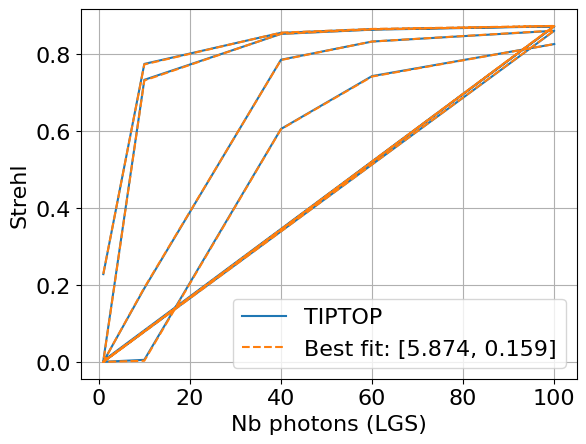

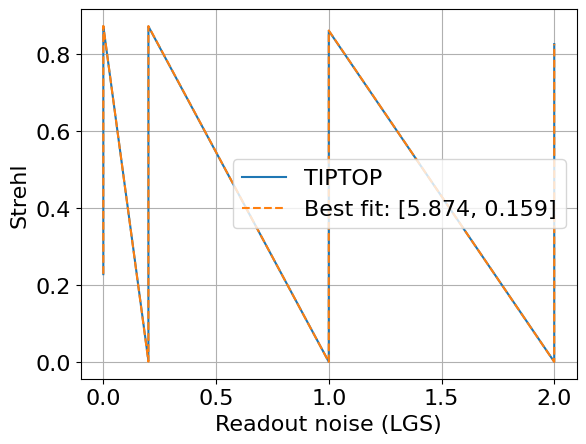

In [11]:
# CALIBRATION OF THE PHOTON and READOUT NOISES ERROR /!\ Run for LO and LGS /!\#
################################################################################

##### Parameters #####
# File parameter
flag_WFS = 'LGS'

if flag_WFS == 'LGS':
    name_error = 'ph_ron_LGS'
    list_n_ph = np.array([1.0,10.0,40.0,60.0,100.0])
    list_ron = np.array([0.0, eval(config_0['sensor_LO']['SigmaRON']), 1.0, 2.0])
    coeff_0 = [7, 0.1]
    lambda_eq = aspro.arcsecond2rad(1) * D_WFS_LGS
    ExcessNoiseFactor = eval(config_0['sensor_HO']['ExcessNoiseFactor'])
    PixScale = eval(config_0['sensor_HO']['PixelScale'])/1000
    FOV = eval(config_0['sensor_HO']['FieldOfView'])
    g_loop = g_loop_LGS
    sensor2update = 'sensor_HO'
elif flag_WFS == 'LO':
    name_error = 'ph_ron_LO'
    # list_n_ph = np.array([0.001,1.0,10.0,40.0,60.0,100.0])
    # list_ron = np.array([0.0, eval(config_0['sensor_LO']['SigmaRON']), 1.0, 2.0])
    list_n_ph = np.array([0.001,0.01,0.1,0.2,0.4,0.7,1.0,2.0,4.0,7.0,10.0,20.0,40.0,70.0,100.0])
    list_ron = np.array([eval(config_0['sensor_LO']['SigmaRON'])])
    coeff_0 = [7, 0.1]
    lambda_eq = lambda_ngs
    ExcessNoiseFactor = eval(config_0['sensor_LO']['ExcessNoiseFactor'])
    PixScale = eval(config_0['sensor_LO']['PixelScale'])/1000
    FOV = eval(config_0['sensor_LO']['FieldOfView'])
    g_loop = g_loop_LO
    sensor2update = 'sensor_LO'
else:
    raise ValueError(flag_mode + \
        ' -> Unknown mode (LGS / LO)') 

# Loop on the number of photons
n_ph = list_n_ph.shape[0]
n_ron = list_ron.shape[0]
list_n_ph, list_ron = np.meshgrid(list_n_ph, list_ron)

list_val = np.zeros([n_ph*n_ron, 2])
list_val[:,0] = list_n_ph.reshape(-1)
list_val[:,1] = list_ron.reshape(-1)

def update_config(config, var):
    config[sensor2update]['NumberPhotons'] = '[%s]'%(var[0])
    config[sensor2update]['SigmaRON'] = '%f'%(var[1])

    return config

x_label = ['Nb photons (' + flag_WFS + ')', 'Readout noise (' + flag_WFS + ')']
##### Parameters #####

##### Simulation and fitting #####
[SR, coeff, SR_0] = fit_tiptop.calib_error( \
    path_results, name_error, list_val, \
    lambda config, var:update_config(config, var), \
    # lambda coeff, list_val:Strehl_ph_LO([coeff[0]], list_val[:,0:1])*Strehl_ron_LO([coeff[1]], list_val[:,1:2], list_val[:,0:1]), \
    # lambda coeff, list_val:Strehl_ph_LGS([coeff[0]], list_val[:,0:1])*Strehl_ron_LGS([coeff[1]], list_val[:,1:2], list_val[:,0:1]), \
    lambda coeff, list_ph_ron: \
        aspro.Strehl_ph([coeff[0]], list_ph_ron[:,0:1], \
            lambda_sci, lambda_eq, g_loop, ExcessNoiseFactor) * \
        aspro.Strehl_ron([coeff[1]], list_ph_ron[:,1:2], list_ph_ron[:,0:1], \
            PixScale, FOV, g_loop), 
    coeff_0, x_label)
##### Simulation and fitting #####

##### Storing and saving ######
config_0['Strehl'][name_error] = np.array2string(coeff, separator=', ')
with open(path_results + 'config_0.ini', 'w') \
    as configfile: config_0.write(configfile)
##### Storing and saving ######

LO part is present
******** HO PSD science and NGSs directions
SLAO case adding cone effect
extra error in nm RMS:  0
extra error spatial frequency exponent:  -2
extra error in nm RMS (LO):  0
extra error spatial frequency exponent (LO):  -2
Required time for total calculation (ms)	 : 276.263714
Required time for AO system model init (ms)	 : 5.820751
Required time for frequency domain init (ms)	 : 96.804380
Required time for final PSD calculation (ms)	 : 166.970015
Required time for aliasing PSD calculation (ms)	 : 71.204662
Required time for focal Aniso PSD calc. (ms)	 : 48.107624
Required time for extra PSD (LO) calc. (ms)	 : 14.682531
Required time for tilt filter calculation (ms)	 : 32.975197
PSD step: 0.030851779706970468
PSD freq range: 7.89805560498444
PSD shape: (2, 256, 256)
oversampling: 1
sensor_science.PixelScale: 14
******** LO PART
******** LO PSF - NGS directions (1 sub-aperture)
SR(@ 750 nm)        : 0.30279
FWHM(@ 750 nm) [mas]: 70.332
EE                   : 0.46792
ma

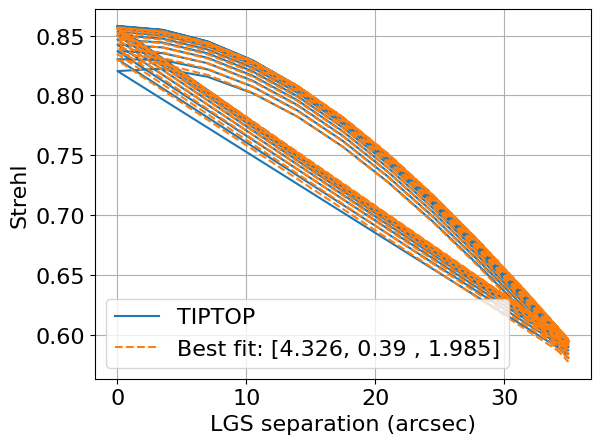

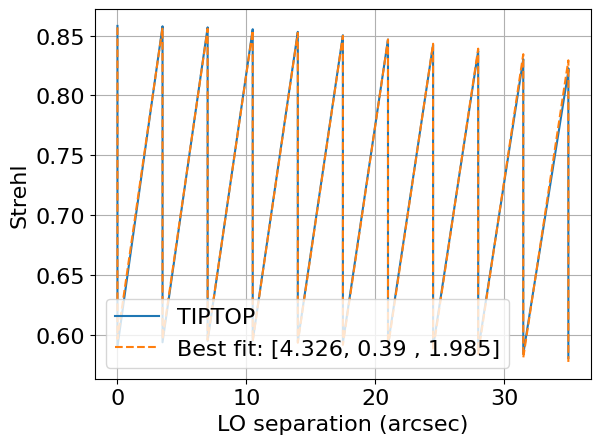

In [9]:
# CALIBRATION OF THE ISOPLANETISM ERROR #
#########################################

##### Parameters #####
# File parameter
name_error = 'isopla'
coeff_0 = [2.0, 0.9, 1.6]

# Building test grid
n_theta_LGS = 11
n_theta_LO = 11
theta_LGS_max = 35.0
theta_LO_max = 35.0
list_theta_LGS = np.linspace(0, theta_LGS_max, n_theta_LGS)
list_theta_LO = np.linspace(0, theta_LO_max, n_theta_LO)

list_theta_LGS, list_theta_LO = np.meshgrid(list_theta_LGS, list_theta_LO)
# list_theta_LO, list_theta_LGS = np.meshgrid(list_theta_LO, list_theta_LGS)

list_val = np.zeros([n_theta_LGS*n_theta_LO, 2])
list_val[:,0] = list_theta_LGS.reshape(-1)
list_val[:,1] = list_theta_LO.reshape(-1)


def update_config(config, var):
    config['sources_HO']['Zenith'] = '[%f]'%(var[0])
    config['sources_LO']['Zenith'] = '[%f]'%(var[1])
    config['atmosphere']['WindDirection'] = '[%f]'%(0.0)
    
    return config

x_label = ['LGS separation (arcsec)', 'LO separation (arcsec)']
##### Parameters #####


##### Simulation and fitting #####
[SR, coeff, SR_0] = fit_tiptop.calib_error( \
    path_results, name_error, list_val, \
    lambda config, var:update_config(config, var), \
    lambda coeff, list_val:aspro.Strehl_iso_LGS(coeff, airmass, np.abs(list_val[:,0:1]), np.abs(list_val[:,1:2]), h_0, r_0, lambda_sci), \
    coeff_0, x_label)
print('SR_0: %f'%(SR_0))
##### Simulation and fitting #####

##### Storing and saving ######
config_0['Strehl']['iso'] = np.array2string(coeff, separator=', ')
with open(path_results + 'config_0.ini', 'w') \
    as configfile: config_0.write(configfile)
##### Storing and saving ######

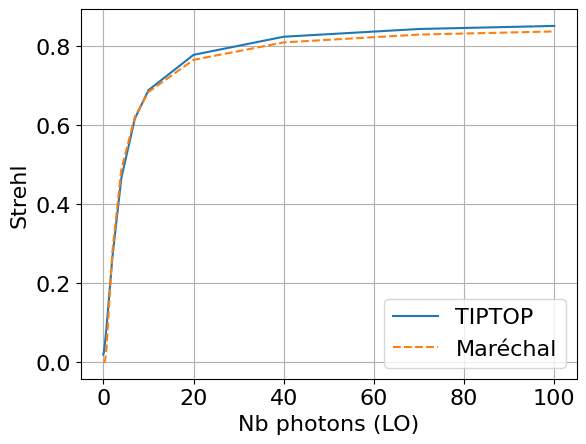

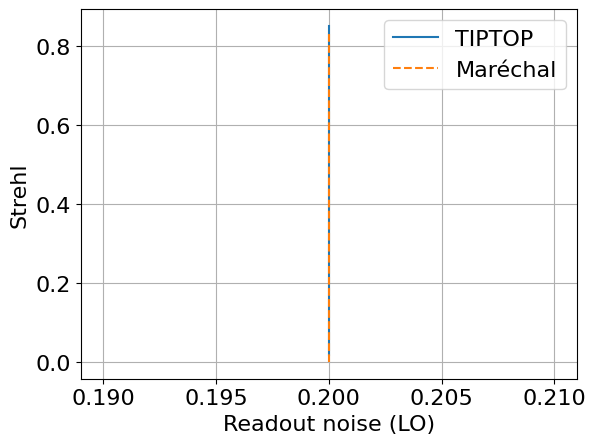

In [14]:
# TESTING MARECHAL APPROXIMATION ON THE CALIBRATED FILES #
##########################################################
from astropy.io import fits
import matplotlib.pyplot as plt

import importlib
importlib.reload(fit_tiptop)

# name_error = 'geom'
# x_label = ['DM pitch (m)']
# name_error = 'cone'
# x_label = ['h_0 (m)']
# name_error = 'lag'
# x_label = ['Wind speed (m.s-1)', 'LGS frequency (Hz)', 'LO frequency (Hz)']
flag_WFS = 'LO'
name_error = 'ph_ron_' + flag_WFS
x_label = ['Nb photons (' + flag_WFS + ')', 'Readout noise (' + flag_WFS + ')']
# name_error = 'isopla'
# x_label = ['LGS separation (arcsec)', 'LO separation (arcsec)']

# Loading results
path_results_error = path_results + '/' + name_error + '/'

config_0 = configparser.ConfigParser()
config_0.optionxform = str # Needed to be case sensitive
config_0.read(path_results + 'config_0.ini')

list_val = []
dat = fits.getdata(path_results_error + 'list_val.fits')
list_val.append(dat)
list_val = list_val[0]

list_SR_TIPTOP = []
dat = fits.getdata(path_results_error + 'list_SR.fits')
list_SR_TIPTOP.append(dat)
list_SR_TIPTOP = list_SR_TIPTOP[0]

dat = []

# Loop on the configuration files
var_nb = list_val.shape[0]

list_SR_Maréchal = np.zeros(var_nb)
for i in range(var_nb):
    # File suffix
    suf_file = '_%i'%(i)

    # Opening configuration
    config_temp = configparser.ConfigParser()
    config_temp.optionxform = str # Needed to be case sensitive
    config_temp.read(path_results_error + name_error + suf_file + '.ini')

    # Adding the Strehl parameters
    config_temp['Strehl']['geom'] = config_0['Strehl']['geom'] 
    config_temp['Strehl']['cone'] = config_0['Strehl']['cone'] 
    config_temp['Strehl']['lag'] = config_0['Strehl']['lag'] 
    config_temp['Strehl']['ph_ron_LGS'] = config_0['Strehl']['ph_ron_LGS'] 
    config_temp['Strehl']['ph_ron_LO'] = config_0['Strehl']['ph_ron_LO'] 
    config_temp['Strehl']['iso'] = config_0['Strehl']['iso']

    # Saving temporary configuration
    with open(path_results + 'config_temp.ini', 'w') \
        as configfile: config_temp.write(configfile)

    # Running Maréchal approximation
    list_SR_Maréchal[i] = fit_tiptop.compute_Maréchal_LGS(path_results, 'config_temp')

    # Removing temporary file
    os.remove(path_results + 'config_temp.ini')

# Display
for i in range(list_val.shape[1]):
    plt.figure(i)
    plt.clf()
    plt.plot(list_val[:,i], list_SR_TIPTOP, label = 'TIPTOP')
    plt.plot(list_val[:,i], list_SR_Maréchal, label = 'Maréchal', linestyle = 'dashed')
    plt.xlabel(x_label[i])
    plt.ylabel('Strehl')
    plt.grid()
    plt.legend()

LO part is present
******** HO PSD science and NGSs directions
SLAO case adding cone effect
extra error in nm RMS:  0
extra error spatial frequency exponent:  -2
extra error in nm RMS (LO):  0
extra error spatial frequency exponent (LO):  -2
Required time for total calculation (ms)	 : 247.428179
Required time for AO system model init (ms)	 : 5.032063
Required time for frequency domain init (ms)	 : 79.403877
Required time for final PSD calculation (ms)	 : 155.039072
Required time for fitting PSD calculation (ms)	 : 2.003908
Required time for aliasing PSD calculation (ms)	 : 68.547964
Required time for focal Aniso PSD calc. (ms)	 : 52.621603
Required time for extra PSD (LO) calc. (ms)	 : 6.896734
Required time for tilt filter calculation (ms)	 : 21.963596
PSD step: 0.030851779706970468
PSD freq range: 7.89805560498444
PSD shape: (2, 256, 256)
oversampling: 1
sensor_science.PixelScale: 14
******** LO PART
******** LO PSF - NGS directions (1 sub-aperture)
SR(@ 750 nm)        : 0.30279
FWHM

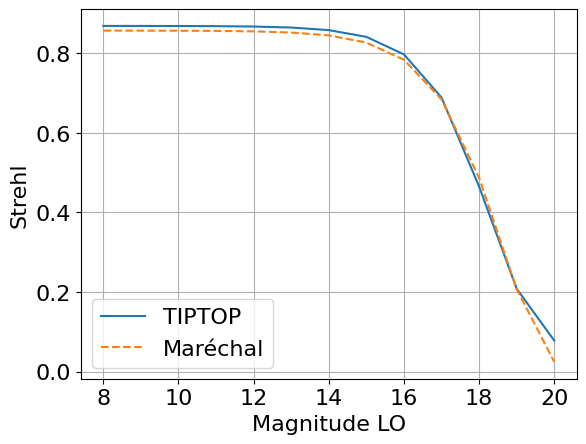

In [5]:
# TESTING MARECHAL APPROXIMATION ON OTHER PARAMETERS #
######################################################

# Python
import os
import numpy as np
import configparser

from astropy.io import fits
import matplotlib.pyplot as plt

##### Parameters #####

# Global paths
flag_mode = 'LGS_VIS' # LGS_VIS/LGS_IR
path = os.getcwd() + '/'
path_config_0 = path + 'config_0/'
path_results = path + 'results/Maréchal_calibration/' + flag_mode + '/'


# Error type
name_error = 'Magnitude'

if name_error == 'Zenith':
    # Loop on the zenith angle
    x_label = 'Zenith angle (deg)'

    var_min = 0
    var_max = 70
    var_delta = 10
    var_nb = round((var_max-var_min)/var_delta+1)
    list_val = np.zeros([var_nb, 1])
    list_val[:,0] = np.linspace(var_min, var_max, var_nb)

    def update_config(config, var):
        config['telescope']['ZenithAngle'] = '%f'%(var)
        # config['atmosphere']['Cn2Heights'] = '[%f]'%(0*1000.0)
        config['atmosphere']['Cn2Heights'] = '[%f]'%(1000.0)
        
        # config['atmosphere']['WindDirection'] = '[%f]'%(0.0)
        # config['atmosphere']['WindSpeed'] = '[0.0001]'
        # config['atmosphere']['WindDirection'] = '[0.0]'
        # config['sensor_HO']['NumberPhotons'] = '[100000]'
        # config['sensor_HO']['SigmaRON'] = '%f'%(0.0)
        # config['sensor_LO']['NumberPhotons'] = '[100000]'
        # config['sensor_LO']['SigmaRON'] = '%f'%(0.0)
        # config['sources_science']['Zenith'] = '[0.0]'

        # config['atmosphere']['WindDirection'] = '[%f]'%(0.0)
        # config['atmosphere']['WindSpeed'] = '[75]'
        # config['atmosphere']['WindDirection'] = '[0.0]'
        # config['sensor_HO']['NumberPhotons'] = '[100000]'
        # config['sensor_HO']['SigmaRON'] = '%f'%(0.0)
        # config['sources_science']['Zenith'] = '[0.0]'

        # config['atmosphere']['WindDirection'] = '[%f]'%(0.0)
        # config['atmosphere']['WindSpeed'] = '[0.0001]'
        # config['atmosphere']['WindDirection'] = '[0.0]'
        # config['sensor_HO']['NumberPhotons'] = '[100000]'
        # config['sensor_HO']['SigmaRON'] = '%f'%(0.0)
        # config['sources_science']['Zenith'] = '[5.0]'
                
        return config

elif name_error == 'Magnitude':

    # Loop on the magnitude
    x_label = 'Magnitude LO'

    var_min = 8
    var_max = 20
    var_delta = 1.0
    var_nb = round((var_max-var_min)/var_delta+1)
    list_val = np.zeros([var_nb, 1])
    list_val[:,0] = np.linspace(var_min, var_max, var_nb)

    def update_config(config, var):
        # Lenslet diameter
        D_WFS_LO = \
            eval(config['telescope']['TelescopeDiameter']) / \
            eval(config['sensor_LO']['NumberLenslets'])[0]
        n_ph = WFS_transmission * D_WFS_LO**2 * \
            mag2flux*10**(-var[0]/2.5) / \
            eval(config['RTC']['SensorFrameRate_LO'])
        config['sensor_LO']['NumberPhotons'] = '[%s]'%(n_ph)

        # # Removing cone effect
        # config['atmosphere']['Cn2Heights'] = '[%f]'%(0)

        # # Removing servo-lag
        # config['atmosphere']['WindSpeed'] = '[0.0001]'

        # # Removing RON
        # config['sensor_LO']['SigmaRON'] = '%f'%(0.0)

        return config

elif name_error == 'Iso':
    # Loop on the wavelength
    x_label = 'Science angular separation (deg)'
    # x_label = 'LGS+LO angular separation (deg)'

    var_min = 0
    var_max = 45
    var_delta = 5.0
    var_nb = round((var_max-var_min)/var_delta+1)
    list_val = np.zeros([var_nb, 1])
    list_val[:,0] = np.linspace(var_min, var_max, var_nb)

    def update_config(config, var):
        # config['sources_science']['Zenith'] = '[%f]'%(var[0])
        config['sources_HO']['Zenith'] = '[%f]'%(var[0])
        config['sources_LO']['Zenith'] = '[%f]'%(var[0])
        config['atmosphere']['WindDirection'] = '[%f]'%(0.0)

        return config
    
elif name_error == 'wavelength_sci':
    # Loop on the wavelength
    x_label = 'Wavelength (mum)'

    var_min = 0.500
    var_max = 10.5
    var_delta = 1.0
    var_nb = round((var_max-var_min)/var_delta+1)
    list_val = np.zeros([var_nb, 1])
    list_val[:,0] = np.linspace(var_min, var_max, var_nb)

    def update_config(config, var):
        config['sources_science']['Wavelength'] = '[%e]'%(var/10**6)
        config['telescope']['TechnicalFoV'] = '240'
        config['sensor_science']['PixelScale'] = '%f'%(var/8e6*180/np.pi*3600*1000/4)
        config['sensor_science']['FieldOfView'] = '512'

        return config

elif name_error == 'wavelength_ngs':
    # Loop on the wavelength
    x_label = 'Wavelength NGS (mum)'

    var_min = 0.500
    var_max = 3.0
    var_delta = 0.5
    var_nb = round((var_max-var_min)/var_delta+1)
    list_val = np.zeros([var_nb, 1])
    list_val[:,0] = np.linspace(var_min, var_max, var_nb)

    def update_config(config, var):
        config['sources_LO']['Wavelength'] = '[%e]'%(var/10**6)

        return config

elif name_error == 'g_loop_LGS':
    # Loop on the gain
    x_label = 'LGS loop gain'

    var_min = 0.1
    var_max = 0.5
    # var_min = 0.3
    # var_max = 0.7
    var_delta = 0.05
    var_nb = round((var_max-var_min)/var_delta+1)
    list_val = np.zeros([var_nb, 1])
    list_val[:,0] = np.linspace(var_min, var_max, var_nb)

    def update_config(config, var):
        config['RTC']['LoopGain_HO'] = '%f'%(var)
        config['atmosphere']['WindSpeed'] = '[0.1]'
        config['sensor_HO']['NumberPhotons'] = '[10]'
        # config['atmosphere']['WindSpeed'] = '[35]'
        # config['sensor_HO']['NumberPhotons'] = '[200]'
        return config

elif name_error == 'g_loop_LO':
    # Loop on the gain
    x_label = 'LO loop gain'

    # var_min = 0.1
    # var_max = 0.5
    var_min = 0.3
    var_max = 0.7
    var_delta = 0.05
    var_nb = round((var_max-var_min)/var_delta+1)
    list_val = np.zeros([var_nb, 1])
    list_val[:,0] = np.linspace(var_min, var_max, var_nb)

    def update_config(config, var):
        config['RTC']['LoopGain_LO'] = '%f'%(var)
        # config['atmosphere']['WindSpeed'] = '[0.1]'
        # config['sensor_LO']['NumberPhotons'] = '[10]'
        config['atmosphere']['WindSpeed'] = '[35]'
        config['sensor_LO']['NumberPhotons'] = '[200]'
        return config

elif name_error == 'turb_layer':
    # Loop on the gain
    x_label = 'Mixing coefficient'

    var_min = 0.0
    var_max = 1.0
    var_delta = 0.1
    var_nb = round((var_max-var_min)/var_delta+1)
    list_val = np.zeros([var_nb, 1])
    list_val[:,0] = np.linspace(var_min, var_max, var_nb)

    def update_config(config, var):
        config['atmosphere']['Cn2Weights'] = '[%f, %f]'%(1-var, var)

        # config['atmosphere']['WindSpeed'] = '[35, 100]'
        # config['atmosphere']['Cn2Heights'] = '[1000, 1000]'
        # config['atmosphere']['WindDirection'] = '[0.0, 0.0]'
        # config['sources_science']['Zenith'] = '[0.0]'
        
        config['atmosphere']['WindSpeed'] = '[35, 35]'
        config['atmosphere']['Cn2Heights'] = '[0000, 2500]'
        config['atmosphere']['WindDirection'] = '[0.0, 0.0]'
        config['sources_science']['Zenith'] = '[3.0]'

        # config['atmosphere']['WindSpeed'] = '[35, 100]'
        # config['atmosphere']['Cn2Heights'] = '[0000, 2500]'
        # config['atmosphere']['WindDirection'] = '[0.0, 0.0]'
        # config['sources_science']['Zenith'] = '[3.0]'
        
        return config

elif name_error == 'pix_scale':
    # Loop on the gain
    x_label = 'Pixel scale'

    var_min = 100
    var_max = 2000
    var_delta = 100
    var_nb = round((var_max-var_min)/var_delta+1)
    list_val = np.linspace(var_min, var_max, var_nb)

    def update_config(config, var):
        config['sensor_HO']['PixelScale'] = '%f'%(var)
        return config

elif name_error == 'N_pix':
    # Loop on the gain
    x_label = 'Number of pixels'

    var_min = 6
    var_max = 12
    var_delta = 1
    var_nb = round((var_max-var_min)/var_delta+1)
    list_val = np.linspace(var_min, var_max, var_nb)

    def update_config(config, var):
        config['sensor_HO']['FieldOfView'] = '%f'%(var)
        return config

elif name_error == 'freq_LGS':
    # Loop on the gain
    x_label = 'LGS loop frequency'

    var_min = 700
    var_max = 1300
    var_delta = 100
    var_nb = round((var_max-var_min)/var_delta+1)
    list_val = np.zeros([var_nb, 1])
    list_val[:,0] = np.linspace(var_min, var_max, var_nb)

    def update_config(config, var):
        config['RTC']['SensorFrameRate_HO'] = '%f'%(var)
        return config

elif name_error == 'freq_LO':
    # Loop on the gain
    x_label = 'LO loop frequency'

    var_min = 100
    var_max = 500
    var_delta = 100
    var_nb = round((var_max-var_min)/var_delta+1)
    list_val = np.zeros([var_nb, 1])
    list_val[:,0] = np.linspace(var_min, var_max, var_nb)

    def update_config(config, var):
        config['RTC']['SensorFrameRate_LO'] = '%f'%(var)
        return config

else:
    raise ValueError('Unknown error')
##### Parameters #####


##### Simulation #####
list_SR_TIPTOP = fit_tiptop.run_simu( \
    path_results, name_error, list_val, \
    lambda config, var:update_config(config, var), \
    x_label)
##### Simulation #####

##### Maréchal #####
path_results_error = path_results + '/' + name_error + '/'
list_SR_Maréchal = np.zeros(var_nb)
for i in range(var_nb):
    # File suffix
    suf_file = '_%i'%(i)

    # Running Maréchal approximation
    list_SR_Maréchal[i] = fit_tiptop.compute_Maréchal_LGS(path_results_error, name_error + suf_file)
##### Maréchal #####

# Display
plt.figure(0)
plt.clf()
plt.plot(list_val, list_SR_TIPTOP, label = 'TIPTOP')
plt.plot(list_val, list_SR_Maréchal, label = 'Maréchal', linestyle = 'dashed')
plt.xlabel(x_label)
plt.ylabel('Strehl')
plt.grid()
plt.legend()


In [ ]:
# # CROSS-TALK CONE EFFECT vs PHOTON NOISE ERROR #
# ################################################

# import importlib
# importlib.reload(aspro)


# ##### Parameters #####
# # File parameter
# name_error = 'cone_vs_ph'
# coeff_0 = [0.7, 2, 130]

# h_lgs = eval(config_0['sources_HO']['Height'])
# D_tel = eval(config_0['telescope']['TelescopeDiameter'])

# Strehl_cone = lambda coeff, list_val:aspro.Strehl_cone( \
#     coeff, airmass, list_val, h_lgs, D_tel, r_0, lambda_sci)
# Strehl_ph_LO = lambda coeff, list_val:aspro.Strehl_ph( \
#     coeff, list_val, lambda_sci, lambda_ngs, \
#     g_loop_LO, eval(config_0['sensor_LO']['ExcessNoiseFactor']))

# # Loop on the number of photons
# list_h0 = np.array([0.0, 1000.0, 2000.0, 4000.0, 8000.0])
# list_n_ph_LO = np.array([10.0,20.0,40.0,60.0,100.0])
# n_h0 = list_h0.shape[0]
# n_ph_LO = list_n_ph_LO.shape[0]
# list_h0, list_n_ph_LO = np.meshgrid(list_h0, list_n_ph_LO)

# list_val = np.zeros([n_h0*n_ph_LO, 2])
# list_val[:,0] = list_h0.reshape(-1)
# list_val[:,1] = list_n_ph_LO.reshape(-1)

# def update_config(config, var):
#     config['atmosphere']['Cn2Heights'] = '[%f]'%(var[0])
#     config['sensor_LO']['NumberPhotons'] = '[%s]'%(var[1])

#     # Removing HO photon noise
#     config['sensor_HO']['NumberPhotons'] = '[%s]'%(50.0)

#     # Removing readout noise
#     config['sensor_HO']['SigmaRON'] = '%f'%(0.0)
#     config['sensor_LO']['SigmaRON'] = '%f'%(0.0)
    
#     # Removing servo-lag
#     config['atmosphere']['WindDirection'] = '[%f]'%(0.0)
#     config['atmosphere']['WindSpeed'] = '[0.01]'

#     return config

# x_label = ['h_0 (m)', 'Nb photons (LO)']
# ##### Parameters #####

# ##### Simulation and fitting #####
# [SR, coeff, SR_0] = aspro.calib_error( \
#     path_results, name_error, list_val, \
#     lambda config, var:update_config(config, var), \
#     lambda coeff, list_val:Strehl_cone(coeff[0:1], list_val[:,0:1])*Strehl_ph_LO([coeff[2]], list_val[:,1:2]), \
#     coeff_0, x_label)
# ##### Simulation and fitting #####

# ##### Storing and saving ######
# config_0['Strehl']['ph'] = np.array2string(coeff, separator=', ')
# with open(path_results + 'config_0.ini', 'w') \
#     as configfile: config_0.write(configfile)
# ##### Storing and saving ######